# BBN abundance evolution

Plots $A_i Y_i(t)$ for each nuclide vs cosmic time, for the **small** (12-reaction,
8-nuclide), **large, amax=8** (68-reaction, 12-nuclide, equivalent to the old
"medium" network) and **large** (~429-reaction, ~59-nuclide) networks, with a secondary axis showing $T_\gamma$ in MeV.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from primat.backend import run_bbn
from primat.plotting import abundance_evolution_curves   # shared, backend-agnostic curve computation
from primat.evolution import t_of_T_interpolator
from primat.config import PRIMATConfig

# Uses primat.backend.run_bbn() only (works on either backend); the curve data
# (t, A_i*Y_i, colour, linestyle, label) comes from the same
# primat.plotting.abundance_evolution_curves() helper the GUI uses, built on
# the EvolutionResult returned as result["evolution"] (output_time_evolution=True).


In [2]:
def add_temperature_axis(ax, evolution, T_ticks_MeV):
    """Add a top x-axis showing T_gamma in MeV."""
    t_of_T = t_of_T_interpolator(evolution)
    t_ticks = [float(t_of_T(T)) for T in T_ticks_MeV]
    ax2 = ax.twiny()
    ax2.set_xscale('log')
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(t_ticks)
    ax2.set_xticklabels([str(T) for T in T_ticks_MeV])
    ax2.set_xlabel(r'$T_\gamma$ [MeV]')
    return ax2

t = np.logspace(0, 6, 500)   # 1 s to 1e6 s
T_ticks_MeV = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01]


## Small network (12 reactions, 8 nuclides)

In [3]:
result_small = run_bbn({'network': 'small', 'verbose': True, 'output_time_evolution': True, 'output_file': None})
cfg_small = PRIMATConfig({'network': 'small'})
A_small = {name: NZ[0] + NZ[1] for name, NZ in cfg_small.Nuclides.items()}
names_small = list(result_small['evolution'].Y)



┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              ┃
┃         ░█▀█░█▀▄░▀█▀░█▄█░█▀█░▀█▀             ┃
┃         ░█▀▀░█▀▄░░█░░█░█░█▀█░░█░             ┃
┃         ░▀░░░▀░▀░▀▀▀░▀░▀░▀░▀░░▀░             ┃
┃                                              ┃
┃    Welcome to PRIMAT (C backend) v0.3.1      ┃
┃                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

[opts-c] backend              = c
[opts-c] network              = small (amax=None)
[opts-c] numerical_precision  = 1e-07
[opts-c] radiative_corrections    = True
[opts-c] finite_mass_corrections  = True
[opts-c] thermal_corrections      = True
[opts-c] spectral_distortions     = True
[opts-c] tau_n_normalization      = True
[opts-c] tau_n                = 878.4 s
[opts-c] Omegabh2             = 0.022425 (eta0b=6.13881e-10)
[opts-c] DeltaNeff            = 0
[init-c] Electron-thermo tables loaded from cache (2000 points).
[init-c] QED pressure correcti

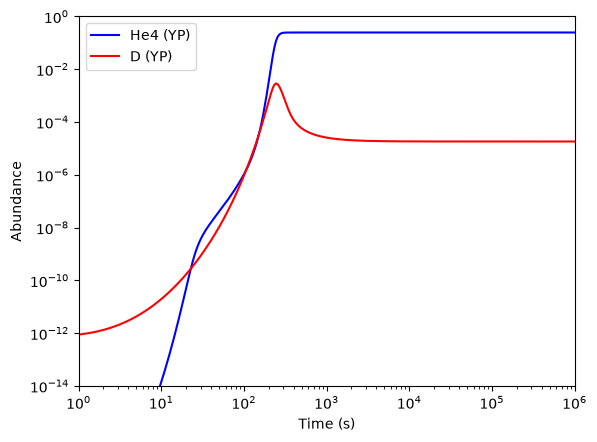

In [4]:
#The following is a simple example of how to plot the evolution of He4 (YP = 4 Y_He4) abundance and D abundance over time using the results from the BBN simulation.
tlist = result_small['evolution'].t
He4list = 4*result_small['evolution'].Y['He4']
dlist = result_small['evolution'].Y['H2']
plt.loglog(tlist, He4list, label='He4 (YP)', color='blue')
plt.loglog(tlist, dlist, label='D (YP)', color='red')
plt.ylim(1e-14, 1e0)
plt.xlim(1e0, 1e6)
plt.xlabel('Time (s)')
plt.ylabel('Abundance')
plt.legend()
plt.show()

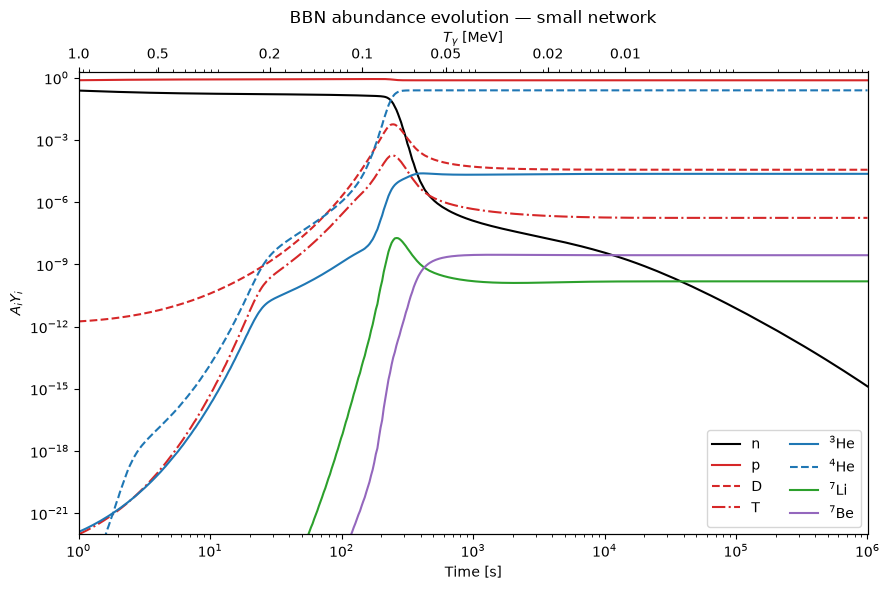

In [5]:
#But we can use the abundance_evolution_curves function to get the curves for all nuclides in the small network.
curves = abundance_evolution_curves(result_small['evolution'], A_small, names_small, t)

fig, ax = plt.subplots(figsize=(9, 6))
for name in names_small:
    t_vals, vals, color, ls, label = curves[name]
    if t_vals.size:
        ax.plot(t_vals, vals, color=color, linestyle=ls, label=label)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$A_i Y_i$')
ax.set_xlim(1, 1e6)
ax.set_ylim(1e-22, 2)
ax.legend(ncol=2)
ax.set_title('BBN abundance evolution — small network')
add_temperature_axis(ax, result_small['evolution'], T_ticks_MeV)

plt.tight_layout()
plt.savefig('plots/abundance_evolution_small.pdf', bbox_inches='tight')
plt.show()


## Large network, amax=8 (68 reactions, 12 nuclides)

In [6]:
result_amax8 = run_bbn({'network': 'large', 'amax': 8, 'verbose': True, 'output_time_evolution': True, 'output_file': None})
cfg_amax8 = PRIMATConfig({'network': 'large', 'amax': 8})
A_amax8 = {name: NZ[0] + NZ[1] for name, NZ in cfg_amax8.Nuclides.items()}
names_amax8 = list(result_amax8['evolution'].Y)



┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              ┃
┃         ░█▀█░█▀▄░▀█▀░█▄█░█▀█░▀█▀             ┃
┃         ░█▀▀░█▀▄░░█░░█░█░█▀█░░█░             ┃
┃         ░▀░░░▀░▀░▀▀▀░▀░▀░▀░▀░░▀░             ┃
┃                                              ┃
┃    Welcome to PRIMAT (C backend) v0.3.1      ┃
┃                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

[opts-c] backend              = c
[opts-c] network              = large (amax=8)
[opts-c] numerical_precision  = 1e-07
[opts-c] radiative_corrections    = True
[opts-c] finite_mass_corrections  = True
[opts-c] thermal_corrections      = True
[opts-c] spectral_distortions     = True
[opts-c] tau_n_normalization      = True
[opts-c] tau_n                = 878.4 s
[opts-c] Omegabh2             = 0.022425 (eta0b=6.13881e-10)
[opts-c] DeltaNeff            = 0
[init-c] Electron-thermo tables loaded from cache (2000 points).
[init-c] QED pressure corrections

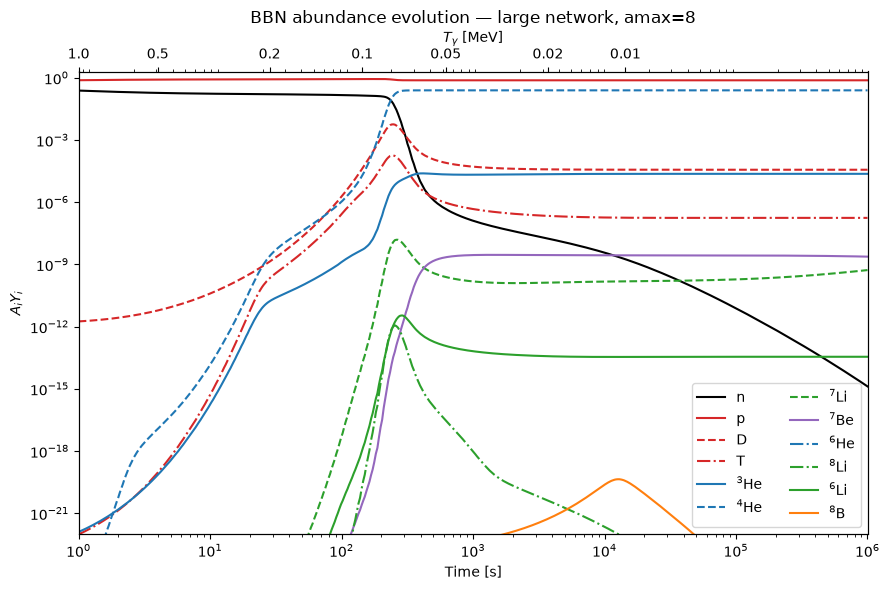

In [7]:
curves = abundance_evolution_curves(result_amax8['evolution'], A_amax8, names_amax8, t)

fig, ax = plt.subplots(figsize=(9, 6))
for name in names_amax8:
    t_vals, vals, color, ls, label = curves[name]
    if t_vals.size:
        ax.plot(t_vals, vals, color=color, linestyle=ls, label=label)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Time [s]'); ax.set_ylabel(r'$A_i Y_i$')
ax.set_xlim(1, 1e6); ax.set_ylim(1e-22, 2)
ax.legend(ncol=2); add_temperature_axis(ax, result_amax8['evolution'], T_ticks_MeV)
ax.set_title('BBN abundance evolution — large network, amax=8')
plt.tight_layout(); plt.show()


## Large network (~429 reactions, ~59 nuclides)

Every tracked nuclide is plotted.  The light elements match the large network, amax=8;
the heavy-nuclide tail is approximate (limited by the AC2024 rate floors).  Lower
`atol_large_LT` (default `1e-25`) to resolve smaller abundances at extra cost.

In [8]:
result_large = run_bbn({'network': 'large', 'verbose': True, 'output_time_evolution': True, 'output_file': None})
# To resolve tinier nuclides, e.g.: run_bbn({'network':'large','atol_large_LT':1e-30, 'output_time_evolution': True, 'output_file': None})
cfg_large = PRIMATConfig({'network': 'large'})
A_large = {name: NZ[0] + NZ[1] for name, NZ in cfg_large.Nuclides.items()}
names_large = list(result_large['evolution'].Y)   # all ~59 tracked nuclides



┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              ┃
┃         ░█▀█░█▀▄░▀█▀░█▄█░█▀█░▀█▀             ┃
┃         ░█▀▀░█▀▄░░█░░█░█░█▀█░░█░             ┃
┃         ░▀░░░▀░▀░▀▀▀░▀░▀░▀░▀░░▀░             ┃
┃                                              ┃
┃    Welcome to PRIMAT (C backend) v0.3.1      ┃
┃                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

[opts-c] backend              = c
[opts-c] network              = large (amax=None)
[opts-c] numerical_precision  = 1e-07
[opts-c] radiative_corrections    = True
[opts-c] finite_mass_corrections  = True
[opts-c] thermal_corrections      = True
[opts-c] spectral_distortions     = True
[opts-c] tau_n_normalization      = True
[opts-c] tau_n                = 878.4 s
[opts-c] Omegabh2             = 0.022425 (eta0b=6.13881e-10)
[opts-c] DeltaNeff            = 0
[init-c] Electron-thermo tables loaded from cache (2000 points).
[init-c] QED pressure correcti

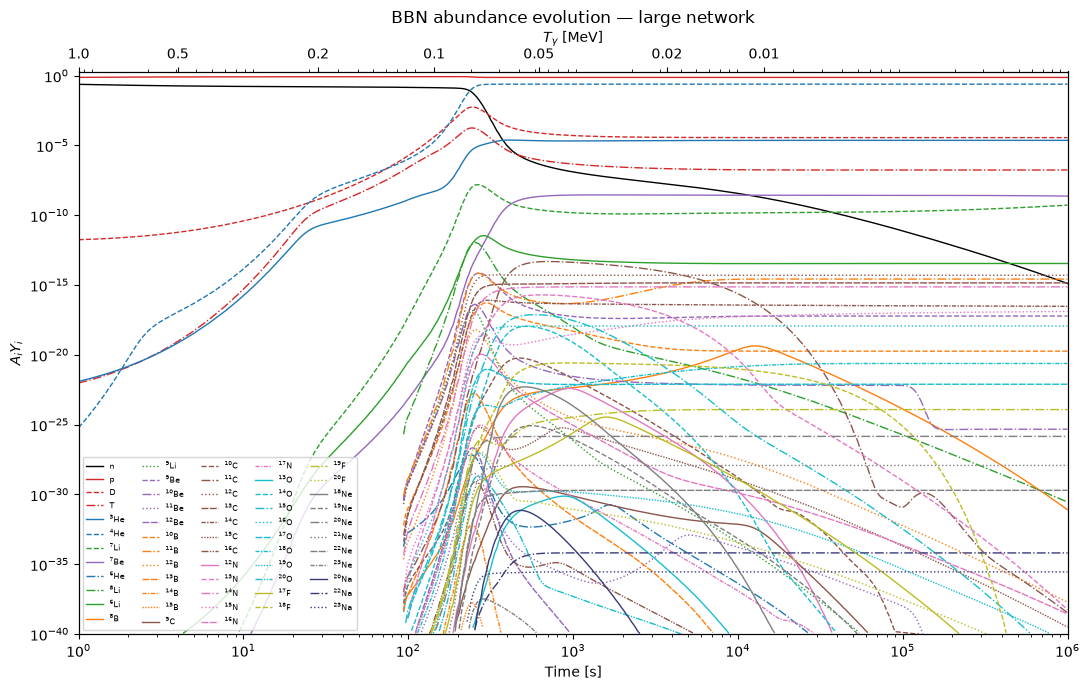

In [9]:
curves = abundance_evolution_curves(result_large['evolution'], A_large, names_large, t)

fig, ax = plt.subplots(figsize=(11, 7))
for name in names_large:
    t_vals, vals, color, ls, label = curves[name]
    mask = vals > 1e-40                        # only drop curves below the y-axis floor
    if mask.any():
        ax.plot(t_vals[mask], vals[mask], color=color, linestyle=ls, lw=1.0, label=label)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Time [s]'); ax.set_ylabel(r'$A_i Y_i$')
ax.set_xlim(1, 1e6); ax.set_ylim(1e-40, 2)
ax.legend(ncol=5, fontsize=6, loc='lower left')
ax.set_title('BBN abundance evolution — large network')
add_temperature_axis(ax, result_large['evolution'], T_ticks_MeV)
plt.tight_layout(); plt.show()
